<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_Desert101_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from pathlib import Path

image_path = Path("/content/drive/MyDrive/desert101")

train_dir = image_path / "train"
test_dir = image_path / "test"

In [10]:
import torch
from torch import nn
import numpy as np

In [196]:
from torchvision import transforms

data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

])

In [197]:
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

class_names = train_data.classes
print(class_names)

['baklava', 'cannoli', 'cup_cakes', 'donuts']


In [198]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [199]:
class DesertClassifier(nn.Module):
    def __init__(self,input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16, out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [200]:
model_0 = DesertClassifier(input_shape=3,hidden_units=32,output_shape=len(class_names))

In [162]:
!pip install torchinfo
from torchinfo import summary
summary(model_0,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [201]:
def train_step(model:torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch,(X,y) in enumerate(dataloader):

        y_pred = model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred) # train accuracy yüzdesi

    train_loss = train_loss / len(dataloader) # batch başına avarage
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [202]:
def test_step(model:torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module):
    model.eval()

    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits,y)

            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss,test_acc

In [203]:
# defualtu verilen şey herneyse en sonda olmak zorunda pythonda
def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.DataLoader,
          test_dataloader:torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs : int = 10):

    results = {"train_loss" : [],
               "train_acc" : [],
               "test_loss" : [],
               "test_acc" : []}

    for epoch in range(epochs):
        train_loss,train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn = loss_fn, optimizer=optimizer)
        test_loss,test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn = loss_fn)

        print(f"Epoch : {epoch} , Train Loss : {train_loss}, Train Acc : {train_acc}, Test Loss : {test_loss}, Test Acc : {test_acc}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss,torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc,torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss,torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc,torch.Tensor) else test_acc)
    return results

In [207]:
EPOCHS = 20
model_0 = DesertClassifier(input_shape=3,hidden_units=64,output_shape=len(class_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.0001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

Epoch : 0 , Train Loss : 1.393730390071869, Train Acc : 0.25625, Test Loss : 1.3845230340957642, Test Acc : 0.3165064102564103
Epoch : 1 , Train Loss : 1.37901873588562, Train Acc : 0.32053571428571426, Test Loss : 1.3666038513183594, Test Acc : 0.4014423076923077
Epoch : 2 , Train Loss : 1.3744375586509705, Train Acc : 0.26517857142857143, Test Loss : 1.3669541676839192, Test Acc : 0.25961538461538464
Epoch : 3 , Train Loss : 1.3529199600219726, Train Acc : 0.371875, Test Loss : 1.352444092432658, Test Acc : 0.2708333333333333
Epoch : 4 , Train Loss : 1.3091150879859925, Train Acc : 0.40758928571428565, Test Loss : 1.3379803895950317, Test Acc : 0.3485576923076923
Epoch : 5 , Train Loss : 1.2545359969139098, Train Acc : 0.45491071428571433, Test Loss : 1.274684468905131, Test Acc : 0.3733974358974359
Epoch : 6 , Train Loss : 1.2226438760757445, Train Acc : 0.46205357142857145, Test Loss : 1.2943446238835652, Test Acc : 0.3798076923076923
Epoch : 7 , Train Loss : 1.1849214076995849, Tr

In [208]:
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

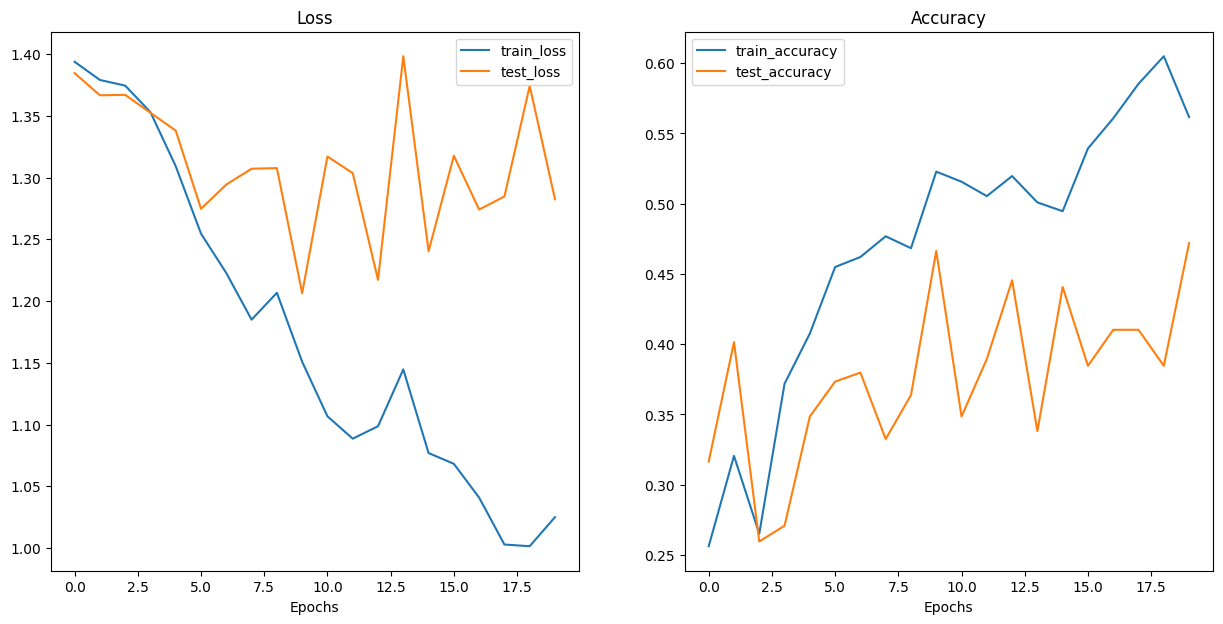

In [209]:
plot_loss_curves(model_0_results)

In [210]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [211]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

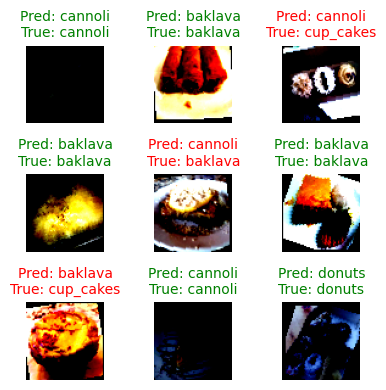

In [257]:
show_random_predictions(model_0, test_data, class_names)

In [282]:
image_path = "/content/drive/MyDrive/images.jpg"

In [283]:
import torchvision

In [284]:
single_image = torchvision.io.read_image(str(image_path))

In [285]:
single_image

tensor([[[ 51,  51,  51,  ...,  91,  91,  91],
         [ 51,  51,  51,  ...,  90,  90,  90],
         [ 51,  51,  51,  ...,  91,  91,  91],
         ...,
         [ 63,  62,  59,  ..., 100, 101, 102],
         [ 64,  69,  54,  ..., 102, 100,  96],
         [ 65,  75,  48,  ...,  95,  89,  80]],

        [[ 50,  50,  50,  ...,  98,  98,  98],
         [ 50,  50,  50,  ...,  97,  97,  97],
         [ 50,  50,  50,  ...,  98,  98,  98],
         ...,
         [ 62,  61,  58,  ..., 103, 104, 105],
         [ 63,  68,  53,  ..., 105, 103,  99],
         [ 64,  74,  47,  ...,  98,  92,  83]],

        [[ 56,  56,  56,  ..., 108, 108, 108],
         [ 56,  56,  56,  ..., 107, 107, 107],
         [ 56,  56,  56,  ..., 108, 108, 108],
         ...,
         [ 68,  67,  64,  ..., 108, 109, 110],
         [ 69,  74,  59,  ..., 110, 108, 104],
         [ 70,  80,  53,  ..., 103,  97,  88]]], dtype=torch.uint8)

In [286]:
single_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

In [287]:
single_image

tensor([[[ 51.,  51.,  51.,  ...,  91.,  91.,  91.],
         [ 51.,  51.,  51.,  ...,  90.,  90.,  90.],
         [ 51.,  51.,  51.,  ...,  91.,  91.,  91.],
         ...,
         [ 63.,  62.,  59.,  ..., 100., 101., 102.],
         [ 64.,  69.,  54.,  ..., 102., 100.,  96.],
         [ 65.,  75.,  48.,  ...,  95.,  89.,  80.]],

        [[ 50.,  50.,  50.,  ...,  98.,  98.,  98.],
         [ 50.,  50.,  50.,  ...,  97.,  97.,  97.],
         [ 50.,  50.,  50.,  ...,  98.,  98.,  98.],
         ...,
         [ 62.,  61.,  58.,  ..., 103., 104., 105.],
         [ 63.,  68.,  53.,  ..., 105., 103.,  99.],
         [ 64.,  74.,  47.,  ...,  98.,  92.,  83.]],

        [[ 56.,  56.,  56.,  ..., 108., 108., 108.],
         [ 56.,  56.,  56.,  ..., 107., 107., 107.],
         [ 56.,  56.,  56.,  ..., 108., 108., 108.],
         ...,
         [ 68.,  67.,  64.,  ..., 108., 109., 110.],
         [ 69.,  74.,  59.,  ..., 110., 108., 104.],
         [ 70.,  80.,  53.,  ..., 103.,  97.,  88.]]]

In [288]:
single_image = single_image / 255

In [289]:
single_image

tensor([[[0.2000, 0.2000, 0.2000,  ..., 0.3569, 0.3569, 0.3569],
         [0.2000, 0.2000, 0.2000,  ..., 0.3529, 0.3529, 0.3529],
         [0.2000, 0.2000, 0.2000,  ..., 0.3569, 0.3569, 0.3569],
         ...,
         [0.2471, 0.2431, 0.2314,  ..., 0.3922, 0.3961, 0.4000],
         [0.2510, 0.2706, 0.2118,  ..., 0.4000, 0.3922, 0.3765],
         [0.2549, 0.2941, 0.1882,  ..., 0.3725, 0.3490, 0.3137]],

        [[0.1961, 0.1961, 0.1961,  ..., 0.3843, 0.3843, 0.3843],
         [0.1961, 0.1961, 0.1961,  ..., 0.3804, 0.3804, 0.3804],
         [0.1961, 0.1961, 0.1961,  ..., 0.3843, 0.3843, 0.3843],
         ...,
         [0.2431, 0.2392, 0.2275,  ..., 0.4039, 0.4078, 0.4118],
         [0.2471, 0.2667, 0.2078,  ..., 0.4118, 0.4039, 0.3882],
         [0.2510, 0.2902, 0.1843,  ..., 0.3843, 0.3608, 0.3255]],

        [[0.2196, 0.2196, 0.2196,  ..., 0.4235, 0.4235, 0.4235],
         [0.2196, 0.2196, 0.2196,  ..., 0.4196, 0.4196, 0.4196],
         [0.2196, 0.2196, 0.2196,  ..., 0.4235, 0.4235, 0.

Text(0.5, 1.0, 'torch.Size([3, 183, 275])')

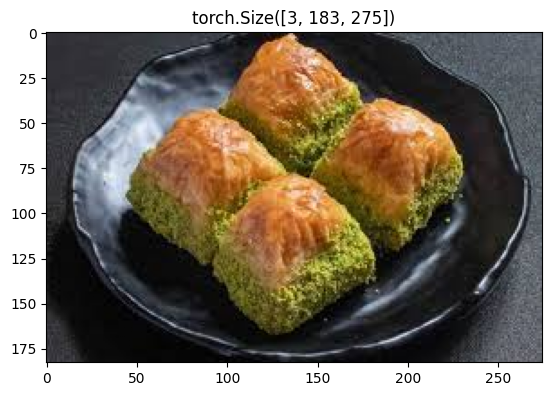

In [290]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [291]:
single_image_transform = transforms.Compose(
    [
          transforms.Resize((64,64)),
          transforms.Normalize(
               [0.485, 0.456, 0.406],
               [0.229, 0.224, 0.225]
    )
    ]
)

single_image = single_image_transform(single_image)

In [292]:
single_image.shape

torch.Size([3, 64, 64])

In [293]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [294]:
single_image = single_image.unsqueeze(dim=0)

In [295]:
model_0.eval()
with torch.inference_mode():
  logits = model_0(single_image)
  probs = torch.softmax(logits,dim=1)
  pred_idx = probs.argmax(dim=1).item()

print("Predicted class : ", class_names[pred_idx])

Predicted class :  baklava
